# Task 4: Spam Detection with Machine Learning
NLP binary classifier (spam vs ham) using TF-IDF with Naive Bayes and Logistic Regression.

**Dataset:** SMS Spam Collection (`spam.csv` from Kaggle: columns `v1` = label, `v2` = text).

In [2]:
import pandas as pd, numpy as np, re
import matplotlib.pyplot as plt, seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## 1. Load data and class distribution

label
ham     4516
spam     653
Name: count, dtype: int64
label
ham     87.37
spam    12.63
Name: count, dtype: float64


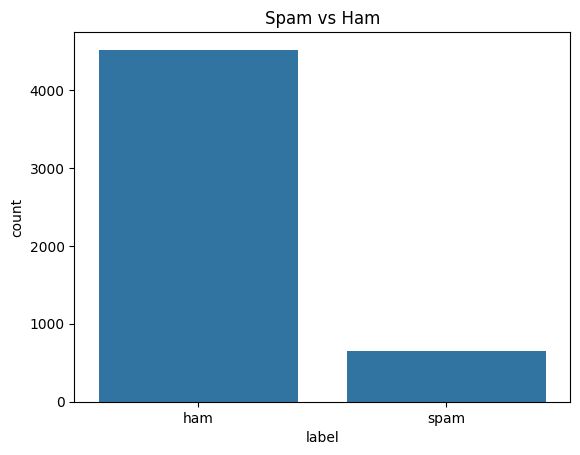

In [3]:
df = pd.read_csv('spam.csv', encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'text']
df = df.drop_duplicates().reset_index(drop=True)
counts = df['label'].value_counts()
print(counts)
print((counts / len(df) * 100).round(2))
sns.countplot(x='label', data=df); plt.title('Spam vs Ham'); plt.show()

## 2. Text preprocessing
Lowercase, strip punctuation/digits, remove stopwords, stem.

In [4]:
stop = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)       # remove punctuation and digits
    words = [stemmer.stem(w) for w in text.split() if w not in stop]
    return ' '.join(words)

df['clean'] = df['text'].apply(clean)
df['y'] = (df['label'] == 'spam').astype(int)
df[['text', 'clean']].head()

,text,clean
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


## 3. TF-IDF feature extraction
**TF-IDF** (Term Frequency × Inverse Document Frequency) scores how important a word is to a message. *TF* is how often the word appears in that message. *IDF* down-weights words that appear in many messages (like "the"), so words that are frequent in one message but rare overall (like "prize" or "winner") get high weights. This turns text into numbers that highlight the distinctive words.

In [5]:
X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    df['clean'], df['y'], test_size=0.2, random_state=42, stratify=df['y'])
tfidf = TfidfVectorizer(max_features=5000)
X_train = tfidf.fit_transform(X_train_txt)   # fit on train only
X_test = tfidf.transform(X_test_txt)
print(X_train.shape, X_test.shape)

(4135, 5000) (1034, 5000)


## 4. Train two classifiers

In [6]:
nb = MultinomialNB().fit(X_train, y_train)
lr = LogisticRegression(max_iter=1000).fit(X_train, y_train)
models = {'Multinomial NB': nb, 'Logistic Regression': lr}

## 5. Evaluation

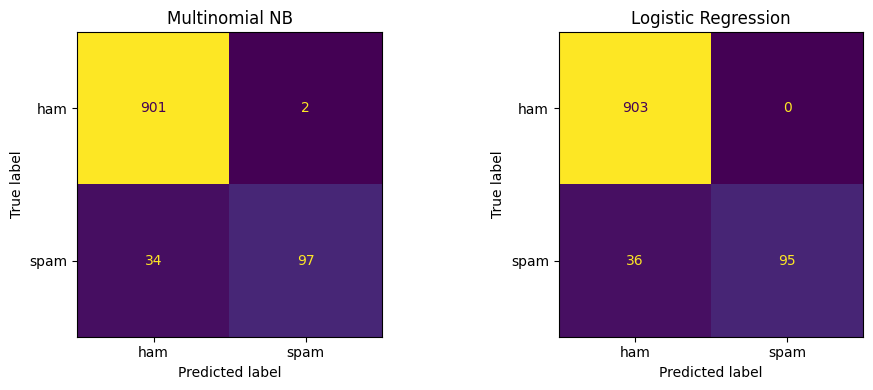

,Accuracy,Precision,Recall,F1
Model,,,,
Multinomial NB,0.9652,0.9798,0.7405,0.8435
Logistic Regression,0.9652,1.0000,0.7252,0.8407


In [7]:
rows = []
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, m) in zip(axes, models.items()):
    p = m.predict(X_test)
    rows.append({'Model': name, 'Accuracy': accuracy_score(y_test, p),
                 'Precision': precision_score(y_test, p), 'Recall': recall_score(y_test, p),
                 'F1': f1_score(y_test, p)})
    ConfusionMatrixDisplay(confusion_matrix(y_test, p), display_labels=['ham', 'spam']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.show()
pd.DataFrame(rows).set_index('Model').round(4)

## 6. Discussion: why is recall important for spam detection?
**Recall** = spam caught ÷ all actual spam. Low recall means spam reaches the inbox, which defeats the filter's purpose and can expose users to phishing and scams. There is a trade-off, though: pushing recall too high flags real mail as spam (false positives), which is costly because users can miss important messages. A good filter keeps recall high while keeping precision high too, which is why F1 is also reported.
**My result:** Multinomial NB has a recall of about 74%, so it catches roughly 3 out of 4 spam messages, while Logistic Regression catches about 73%. The remaining spam messages still reach the inbox, so improving recall is the main way to make this filter better.


## 7. (Bonus) WordClouds
Requires `pip install wordcloud`.

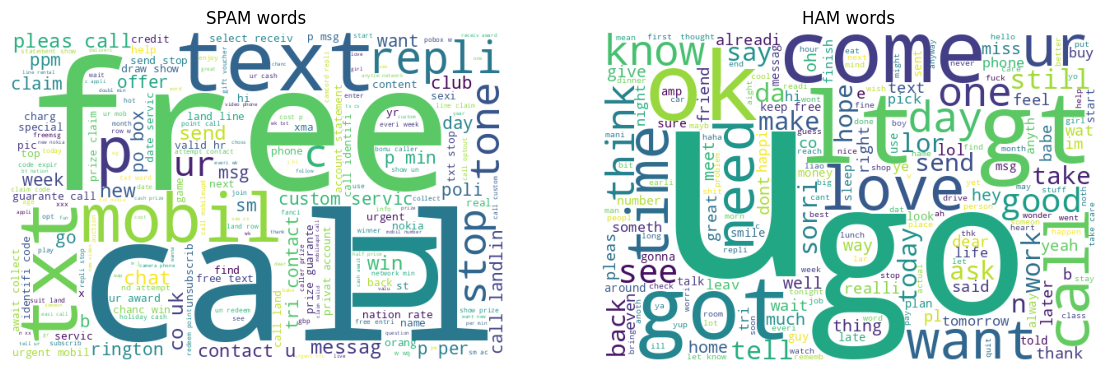

In [8]:
from wordcloud import WordCloud
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, lab in zip(axes, ['spam', 'ham']):
    text = ' '.join(df.loc[df['label'] == lab, 'clean'])
    ax.imshow(WordCloud(width=600, height=400, background_color='white').generate(text))
    ax.set_title(f'{lab.upper()} words'); ax.axis('off')
plt.show()

## 8. Try it on a new message

In [9]:
def predict(msg, model=nb):
    return 'SPAM' if model.predict(tfidf.transform([clean(msg)]))[0] else 'HAM'
print(predict('Congratulations! You won a free prize. Call now to claim'))
print(predict('Hey, are we still meeting for lunch tomorrow?'))

SPAM
HAM


## Conclusion
- Both models reached about 96.5% accuracy on the SMS Spam Collection dataset.
- Multinomial Naive Bayes had slightly better recall (74.05% vs 72.52%) and F1-score (84.35% vs 84.07%), so it caught a bit more spam.
- Logistic Regression had a perfect precision of 100%, meaning it never marked a genuine message as spam, but it missed slightly more spam.
- Overall, Naive Bayes is the better choice when catching spam matters most, and Logistic Regression is safer when we want to avoid blocking genuine messages.
- Recall can be improved further by handling the class imbalance (only about 13% of messages are spam), for example with class weights or by tuning the decision threshold.